# Setup

In [21]:
%load_ext autoreload
%autoreload 2

# %matplotlib widget

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import hist
import mplhep as hep


from rich import print
from matplotlib.colors import LogNorm
from tpvalidator.analysis.histograms import cumsum_hist, cut_scan_to_df, compute_regaxis_specs, make_regaxis, build_histogram

from tpvalidator.viz.tps import TrgPrimitivesPlotter
from tpvalidator.viz.backtracker import BackTrackerPlotter
from tpvalidator.viz.display import TriggerPrimitivesEventViewer
from typing import Literal, Optional


# Analysis

In [23]:
class TPFilterAnalyser:
    
    def __init__(self, bkg_ws, sig_ws):
        self._bkd_ws = bkg_ws
        self._sig_ws = sig_ws


        self.bkg_tpp = TrgPrimitivesPlotter(self._bkd_ws)
        self.sig_tpp = TrgPrimitivesPlotter(self._sig_ws)


        # self.bkg_tpp.var_specs['samples_over_threshold']['bin_size'] = 1

        
    def plot_top_vars_by_generator(self, dataset:Literal['sig', 'bkg'], rop=2, figsize=(16,4), **kwargs):

        match dataset:
            case 'sig':
                tpp = self.sig_tpp
            case 'bkg': 
                tpp = self.bkg_tpp
            case _:
                raise ValueError(f'Dataset {dataset} unknown')

        fig, axes = plt.subplots(1, 3, figsize=figsize)

        tpp.plot_var_by_generator(rop=rop, var_spec='samples_over_threshold', ax=axes[0], **kwargs)
        tpp.plot_var_by_generator(rop=rop, var_spec='adc_peak', ax=axes[1], **kwargs)
        tpp.plot_var_by_generator(rop=rop, var_spec='adc_integral', ax=axes[2], **kwargs)

        fig.tight_layout()

        return fig
    


    def plot_peak_vs_sot(self, weight=None, ke_evf=None, rop=2, query:str=None, cmap:str=None, generator_selection='Ar39GenInLAr', zoom:Optional[dict]=None):

        bkg_tpp = self.bkg_tpp
        sig_tpp = self.sig_tpp

        fig, axes = plt.subplots(3,2, figsize=(12,12))


        common_kwargs = {
            'rop':rop, 
            'weight': weight, 
            'cmap': cmap,
            'query': query
        }

        common_args = [
            'adc_peak', 'samples_over_threshold'
        ]
        row=0

        ax = axes[row][0]
        bkg_tpp.plot_2d_var_dist(*common_args, ax=ax, **common_kwargs)
        ax.set_title('radiologicals (all)')
        ax.grid()


        ax = axes[row][1]
        bkg_tpp.plot_2d_var_dist(*common_args, bt_generator_name=generator_selection, ax=ax, **common_kwargs)
        ax.set_title('Ar39')
        ax.grid()

        #-----

        row=1

        ax = axes[row][0]
        sig_tpp.plot_2d_var_dist(*common_args, ax=ax, **common_kwargs)
        ax.set_title('e-minus [zoom]')
        ax.grid()

        ax = axes[row][1]
        sig_tpp.plot_2d_var_dist(*common_args, ev_filter=ke_evf, ax=ax, **common_kwargs)
        ax.set_title(f'e-minus [zoom][{ke_evf["filter"]}]')
        ax.grid()


        #----
        row=2

        ax = axes[row][0]
        sig_tpp.plot_2d_var_dist(*common_args, ax=ax, **common_kwargs)
        ax.set_title('e-minus')
        ax.grid()

        ax = axes[row][1]
        sig_tpp.plot_2d_var_dist(*common_args, ev_filter=ke_evf, ax=ax, **common_kwargs)
        ax.set_title(f'e-minus [{ke_evf["filter"]}]')
        ax.grid()


        #----

        if zoom:

            xmin = zoom.get('xmin', None)
            xmax = zoom.get('xmax', None)
            ymin = zoom.get('ymin', None)
            ymax = zoom.get('ymax', None)


            for rax in axes[0:2]:
                for ax in rax:
                    ax.set_xlim(xmin, xmax)
                    ax.set_ylim(ymin, ymax)

        fig.suptitle("Trigger Primitives multiplicity in sadc and peak - zoom on the low-E region")
        fig.tight_layout()


        return fig



# Data

In [24]:
import tpvalidator.datacatalogue as dctl

dataset_names = ['eminus', 'radbkg']
# datasets = dctl.load('data/vd/1x8x14/3sig', load_rawadc=False, selection=dataset_names)
datasets = dctl.load('data/vd/1x8x14/preprod', load_rawadc=False, selection=dataset_names)
rad_ws=datasets['radbkg']
em_ws=datasets['eminus']


Loading radbkg

Dataset 'radbkg': 100 events

{
    'backtracker': {'TPAlgTPCSimpleThreshold': {'offset_U': 8, 'offset_V': 1, 'offset_X': -7}},
    'geo': {'detector': 'dunevd10kt_3view_30deg_v5_refactored_1x8x14ref'},
    'mctruth_blockid_map': [
        [28, 'Rn222ChainFromPo218GenInUpperMesh1x8x14'],
        [27, 'Rn220ChainFromPb212GenInUpperMesh1x8x14'],
        [26, 'Kr85GenInLAr'],
        [25, 'Rn222ChainFromBi210GenInUpperMesh1x8x14'],
        [24, 'U238ChainGenInAnode'],
        [23, 'K40GenInCathode'],
        [22, 'K42From42ArGenInUpperMesh1x8x14'],
        [21, 'Th232ChainGenInCathode'],
        [20, 'CavernNGammasAtLAr1x8x14'],
        [19, 'Rn222ChainRn222GenInLAr'],
        [18, 'U238ChainGenInCathode'],
        [17, 'K40GenInAnode'],
        [16, 'Rn220ChainPb212GenInLAr'],
        [15, 'foamGammasAtLAr1x8x14'],
        [14, 'Rn222ChainFromPb214GenInUpperMesh1x8x14'],
        [13, 'K42From42ArGenInLAr'],
        [12, 'Rn222ChainGenInPDS'],
        [11, 'Ar42GenInLAr'],
        [10, 'CavernwallGammasAtLAr1x8x14'],
        [9, 'Rn222ChainPb210GenInLAr'],
        [8, 'Ar39GenInLAr'],
        [7, 'Rn222ChainPb214GenInLAr'],
        [6, 'Rn222ChainFromPb210GenInUpperMesh1x8x14'],
        [5, 'Rn222ChainPo218GenInLAr'],
        [4, 'CavernwallNeutronsAtLAr1x8x14'],
        [3, 'Rn222ChainFromBi214GenInUpperMesh1x8x14'],
        [2, 'CryostatNGammasAtLAr1x8x14'],
        [1, 'Th232ChainGenInAnode'],
        [0, 'Rn222ChainBi214GenInLAr']
    ],
    'tpg': {
        'tpmakerTPCSimpleThreshold::TriggerPrimitiveMaker': {
            'threshold_tpg_plane0': 36,
            'threshold_tpg_plane1': 36,
            'threshold_tpg_plane2': 36,
            'tool': 'TPAlgTPCSimpleThreshold'
        }
    }
}

Loading eminus

Dataset 'eminus': 10000 events

{
    'backtracker': {'TPAlgTPCSimpleThreshold': {'offset_U': 8, 'offset_V': 1, 'offset_X': -7}},
    'geo': {'detector': 'dunevd10kt_3view_30deg_v5_refactored_1x8x14ref'},
    'mctruth_blockid_map': [[0, 'generator']],
    'tpg': {
        'tpmakerTPCSimpleThreshold::TriggerPrimitiveMaker': {
            'threshold_tpg_plane0': 36,
            'threshold_tpg_plane1': 36,
            'threshold_tpg_plane2': 36,
            'tool': 'TPAlgTPCSimpleThreshold'
        }
    }
}

In [25]:
fa = TPFilterAnalyser(rad_ws, em_ws)

# Introduction

TP filtering is applied to reduce the rate of TPs at the input of the TriggerActivity maker algorithm(s).
This is possible becasue a large fraction of the input TPs are from Ar39 decays: they are evenly distributed across in space and time, low in energy (Ar39 e- endpoing at 0.5 MeV).
They do not contribute to or give rise to any deposit with significant energy or extension.
Vice-versa target signals (primarily electrons) in the low-MeV energy range give rise to multi TP, high(er) energy clusters

# Pre-filtering TP rates

The rate of trigger primitives by generator, with only TP threshold cut applied is the following:

In [26]:
rad_tpp = TrgPrimitivesPlotter(rad_ws)

# Background TPs properties

The TP variables distributions for highest backgrounds are:

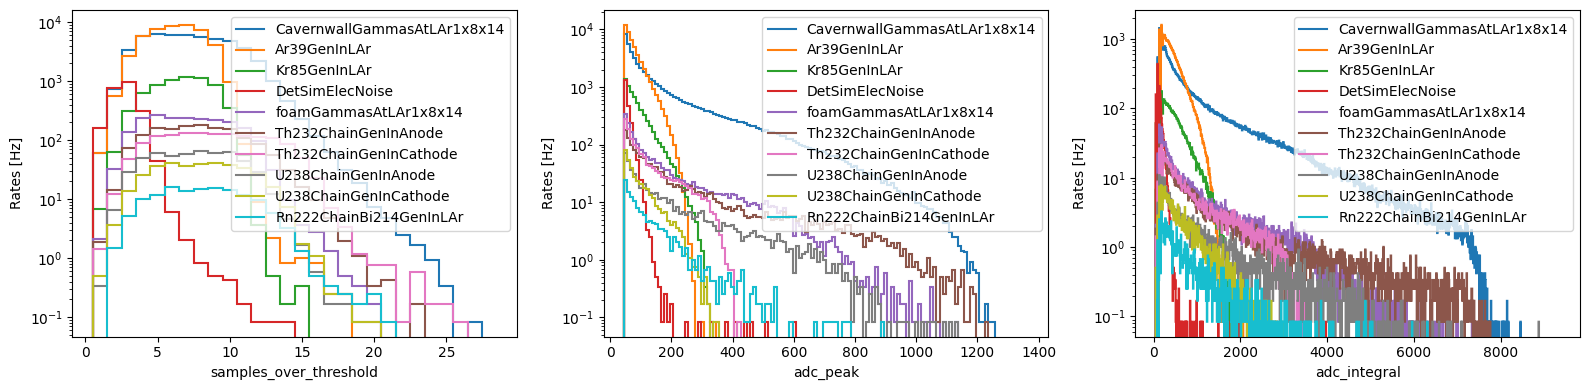

In [27]:
query='adc_peak > 45'
norm='rate'
geo_norm='crp'
n_top=10

fig = fa.plot_top_vars_by_generator('bkg', query=query, norm=norm, geo_norm=geo_norm, n_top=n_top)


In [28]:
print(rad_tpp.make_generator_activity_table('adc_peak >= 45 & readout_plane_id == 2', norm='rate', geo_norm='crp'))


                  Rates per generator (crp)                   
┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃    ┃ generator                               ┃ rate        ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ 3  │ CavernwallGammasAtLAr1x8x14             │ 52479.92 HZ │
│ 1  │ Ar39GenInLAr                            │ 48233.28 HZ │
│ 8  │ Kr85GenInLAr                            │ 6591.93 HZ  │
│ 0  │ DetSimElecNoise                         │ 2680.17 HZ  │
│ 22 │ foamGammasAtLAr1x8x14                   │ 2141.26 HZ  │
│ 18 │ Th232ChainGenInAnode                    │ 1525.55 HZ  │
│ 19 │ Th232ChainGenInCathode                  │ 1456.13 HZ  │
│ 20 │ U238ChainGenInAnode                     │ 548.07 HZ   │
│ 21 │ U238ChainGenInCathode                   │ 373.95 HZ   │
│ 11 │ Rn222ChainBi214GenInLAr                 │ 139.66 HZ   │
│ 13 │ Rn222ChainFromBi214GenInUpperMesh1x8x14 │ 130.76 HZ   │
│ 9  │ Rn220ChainFromPb212GenInUpperMesh1x8x14 │ 101.18 HZ   │
│ 4  │ K40GenInAnode                           │ 99.08 HZ    │
│ 10 │ Rn220ChainPb212GenInLAr                 │ 73.61 HZ    │
│ 5  │ K40GenInCathode                         │ 70.59 HZ    │
│ 15 │ Rn222ChainPb214GenInLAr                 │ 53.36 HZ    │
│ 12 │ Rn222ChainFromBi210GenInUpperMesh1x8x14 │ 35.21 HZ    │
│ 7  │ K42From42ArGenInUpperMesh1x8x14         │ 16.30 HZ    │
│ 14 │ Rn222ChainFromPb214GenInUpperMesh1x8x14 │ 13.70 HZ    │
│ 2  │ Ar42GenInLAr                            │ 4.54 HZ     │
│ 6  │ K42From42ArGenInLAr                     │ 4.20 HZ     │
│ 16 │ Rn222ChainPo218GenInLAr                 │ 3.78 HZ     │
│ 17 │ Rn222ChainRn222GenInLAr                 │ 2.10 HZ     │
└────┴─────────────────────────────────────────┴─────────────┘

## Notes and Observations

- These plots use backtracked TPs. Backtracking has known inefficiencies.
- Ar39 and Kr85 are both concentrated at low samples osve thresholds, peaking at $SOT \simeq 9$, and falling sharply just above $SOT > 10$.
  

# Single Electrons sample

In [29]:
em_tpp = TrgPrimitivesPlotter(em_ws)

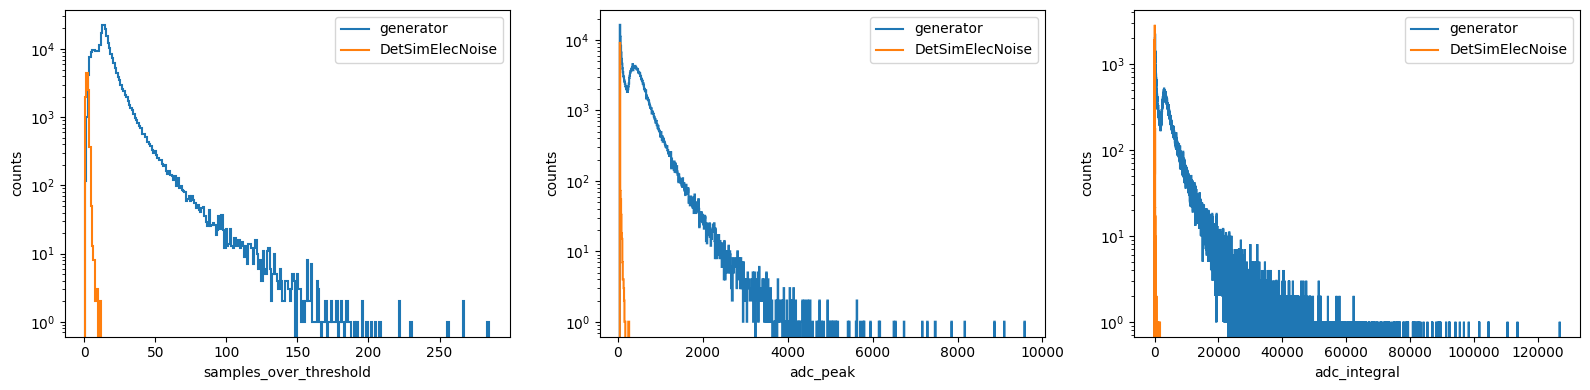

In [30]:
query='adc_peak > 45'
norm='counts'
geo_norm='default'
n_top=10

fig = fa.plot_top_vars_by_generator('sig', query=query, norm=norm, geo_norm=geo_norm, n_top=n_top)


# Radiologicals and Ar39 distributions vs Single Electrons

Comparing the `samples_over_threshold`:`adc_peak` distributions of Ar39 with low-energy electrons provides a better insight of the features that can be exploited

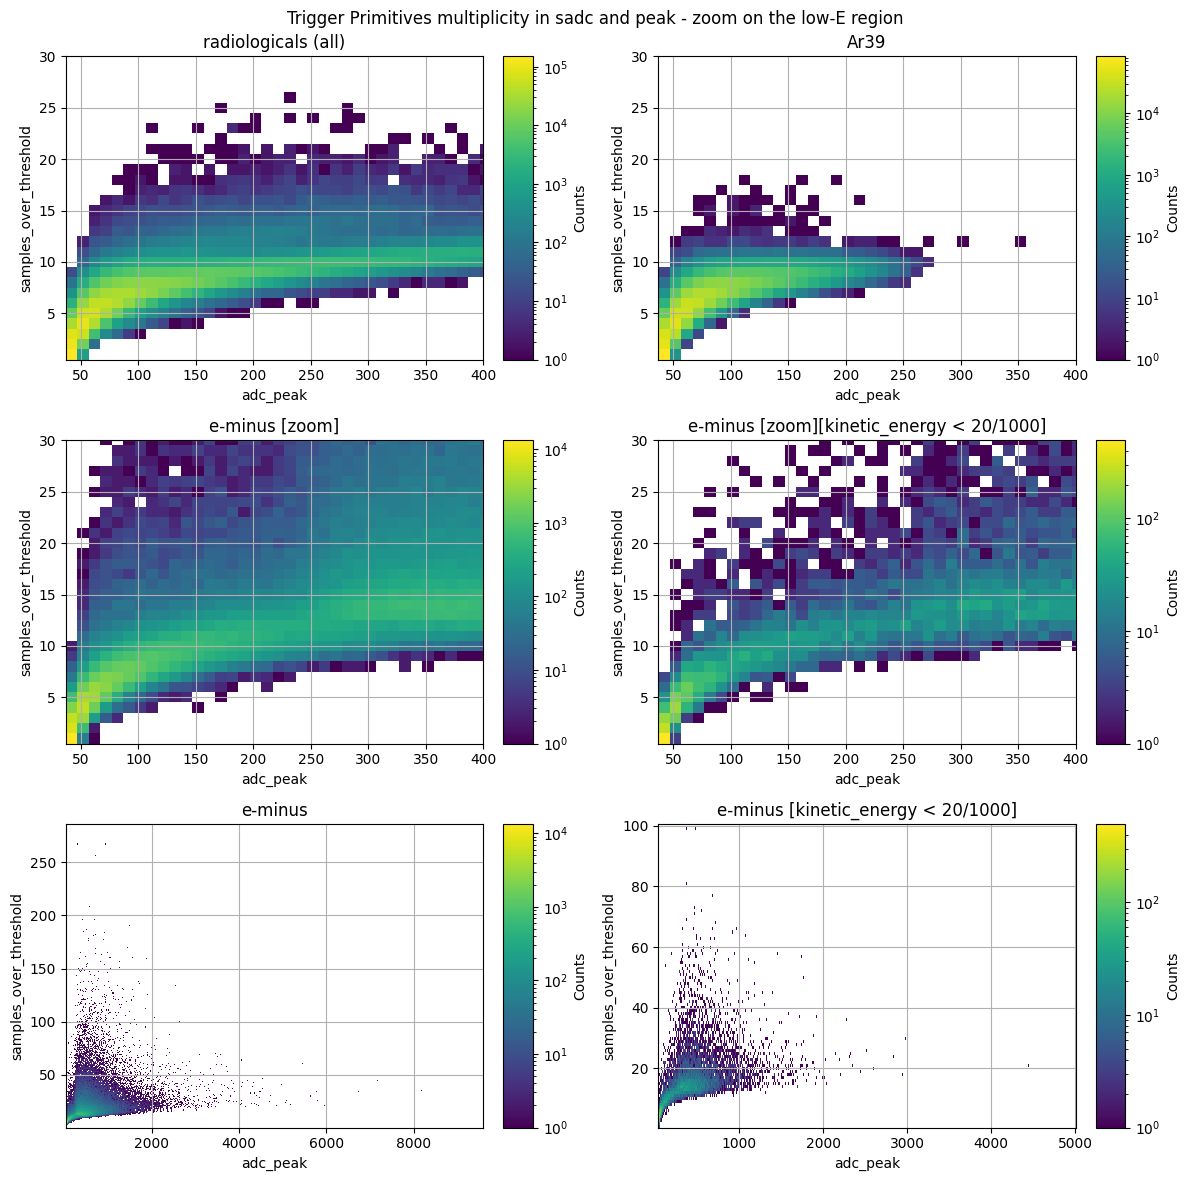

In [31]:
weight=None
query='adc_peak > 45'
rop=2
em_lowe_evf = {'collection':'mctruths', 'filter':'kinetic_energy < 20/1000'}

cmap=None
ar39_name='Ar39GenInLAr'
ar39_zoom = {
    'xmax': 400,
    'ymax': 30
}


fig = fa.plot_peak_vs_sot(weight=weight, query=query, ke_evf=em_lowe_evf, rop=rop, cmap=cmap, generator_selection=ar39_name, zoom=ar39_zoom)



## Observations

- Ar39 TP are confirmed to concentrate at low samples-over threshold values. Only traces remain at SOT > 15 (NOTE: the radiological sample has limited statistics (10 events))
- Single electron TPs extend to much higher values (unsurprisingly), but peak in number close the origin
  
---

# Charge distributions

- From the perspective of clustering and identifying signal among backgrounds, not all TPs are equal.
- In single-e samples, high(er)-`adc_integral` TPs are more valuable for the identification of energy deposit in the MeV range
- The areas in the `adc_peak` / `samples_over_threshold` where the most charge is collected can be identified by weighting the histogram by `adc_intergral`

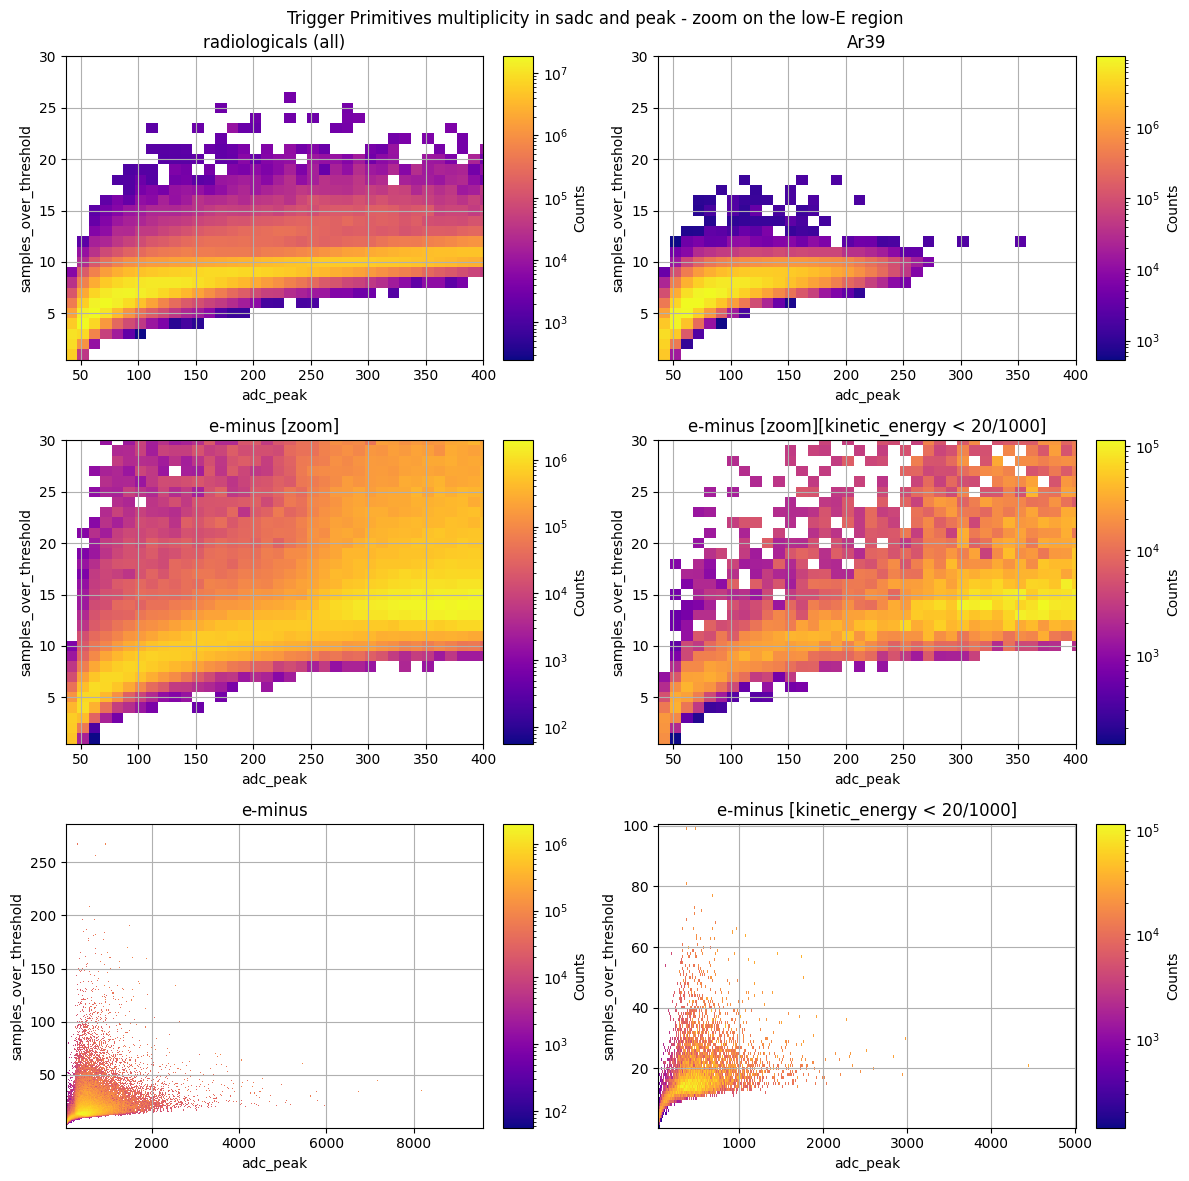

In [32]:
weight='adc_integral'
query='adc_peak > 45'
rop=2
em_lowe_evf = {'collection':'mctruths', 'filter':'kinetic_energy < 20/1000'}
cmap='plasma'

ar39_name='Ar39GenInLAr'
ar39_zoom = {
    'xmax': 400,
    'ymax': 30
}

fig = fa.plot_peak_vs_sot(weight=weight, query=query, ke_evf=em_lowe_evf, rop=rop, cmap=cmap, generator_selection=ar39_name, zoom=ar39_zoom)

## Observations

- The importance of TPs with  `sample_over_threshold < 10` in the e-minus sample is reduced. Most of the charge accumulates at `sample_over_threshold >= 10` (and `adc_peak > 200`)
- A `sample_over_threshold >= 10` filter is not expected to remove a significant charge fraction
- This is true if limiting the event selection to $< 20\ MeV$
  
---